## Hotel Review Sentiment Classification with PyTorch

This notebook mirrors the structure and manual PyTorch workflow used in the class BERT notebook while adapting the task to the hotel-review sentiment dataset.

The model classifies each hotel review as:

- **Negative (`0`)**: overall rating of 1 or 2
- **Positive (`1`)**: overall rating of 4 or 5

Reviews with an overall rating of 3 are removed to maintain a binary classification task.

In [1]:
!pip install -U datasets

## Step 1: Environment Setup and Dataset Access

### A. Optional Hugging Face authentication

In [2]:
from huggingface_hub import HfApi
import os

token = os.environ.get("HF_TOKEN")
api = HfApi()

if token:
    try:
        user_info = api.whoami(token=token)
        print("Hugging Face token is valid.")
        print("Authenticated user:", user_info.get("name", "Unknown"))
    except Exception as error:
        print("The Hugging Face token could not be validated.")
        print("Error:", error)
else:
    print(
        "No HF_TOKEN was found. This is acceptable because "
        "bert-base-uncased is a public model."
    )

No HF_TOKEN was found. This is acceptable because bert-base-uncased is a public model.


### B. Install and import required libraries

In [3]:
# Uncomment this line in a new Colab or Jupyter environment.
# %pip install -q transformers datasets huggingface_hub scikit-learn scipy pandas matplotlib tqdm

In [4]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


### C. Load the hotel-review dataset

Place `hotel_reviews.csv` in the same directory as this notebook or update `DATA_PATH`.

In [5]:
DATA_PATH = "clean_hotel_reviews.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Upload the dataset or update DATA_PATH."
    )

hotel_df = pd.read_csv(DATA_PATH)

print("Original dataset shape:", hotel_df.shape)
print("Columns:", hotel_df.columns.tolist())
display(hotel_df.head())

Original dataset shape: (80122, 9)
Columns: ['overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text', 'sentiment']


,overall,value,service,location,rooms,cleanliness,sleep_quality,review_text,sentiment
0,4.0,4.0,4.0,5.0,4.0,5.0,4.0,“Great Stay” This is a great property in Midto...,1
1,4.0,3.0,4.0,5.0,5.0,5.0,5.0,“Its the best of the Andaz Brand in the US.......,1
2,4.0,4.0,4.0,5.0,4.0,5.0,5.0,“A Nice Stay for NYC!” This hotel is a nice st...,1
3,4.0,5.0,4.0,5.0,5.0,5.0,5.0,“Stunningly Wonderful!” Other hotels in NYC th...,1
4,4.0,4.0,4.0,4.0,4.0,4.0,5.0,"“Modern, minimalist, central hotel” We got a r...",1


## Step 2: Data Preprocessing

Preprocessing includes:

- Inspecting sample reviews and ratings
- Removing missing or empty review text
- Excluding neutral ratings
- Creating binary labels
- Creating training, validation, and test splits
- Tokenizing each review

### A. Explore samples and create sentiment labels

In [6]:
from collections import Counter

required_columns = {"review_text", "overall"}
missing_columns = required_columns.difference(hotel_df.columns)

if missing_columns:
    raise KeyError(
        f"The dataset is missing required columns: {sorted(missing_columns)}"
    )

# Explore a few original samples.
sample_df = hotel_df[["review_text", "overall"]].dropna().head(3)

for sample_number, (_, row) in enumerate(sample_df.iterrows(), start=1):
    print(f"Sample {sample_number}:")
    print("Text:", row["review_text"])
    print("Overall rating:", row["overall"])
    print("---")

# Clean the dataset.
clean_df = hotel_df.copy()
clean_df["review_text"] = clean_df["review_text"].astype("string").str.strip()
clean_df = clean_df.dropna(subset=["review_text", "overall"])
clean_df = clean_df[clean_df["review_text"].str.len() > 0]
clean_df = clean_df[clean_df["overall"] != 3].copy()

# Create binary sentiment labels.
clean_df["label"] = np.where(clean_df["overall"] >= 4, 1, 0)

label_names = {
    0: "Negative",
    1: "Positive",
}

print("\nLabel set:", set(clean_df["label"]))
print("Label distribution:", Counter(clean_df["label"]))
print("Cleaned dataset shape:", clean_df.shape)

display(
    clean_df[
        ["review_text", "overall", "label"]
    ].head()
)

Sample 1:
Text: “Great Stay” This is a great property in Midtown. We two different rooms different rooms during our stay. The first room was in the North tower, which was quite inconvenient. You have to go through the conference area to get to the north elevators. 
The second room was the Andaz Suite. It was nicely appointed room, but the best part about it was the bathroom. From the foot soaking bowl to the bath products, everything about the bathroom was awesome!
Lemon poppy-seed pancakes are must haves at the restaurant. One of the best pancakes ever.
Overall rating: 4.0
---
Sample 2:
Text: “Its the best of the Andaz Brand in the US....” I have stayed at each of the US Andaz properties, and this one is the best of them all. MUCH better than the West Hollywood property where Brand standards are slowly fading. This is the shining star here in the States.
My room (suite) on the 12th floor was fantastic as usual. Perfectly maintained, very comfortable, great bathrooms (best in NYC???). 

,review_text,overall,label
0,“Great Stay” This is a great property in Midto...,4.0,1
1,“Its the best of the Andaz Brand in the US.......,4.0,1
2,“A Nice Stay for NYC!” This hotel is a nice st...,4.0,1
3,“Stunningly Wonderful!” Other hotels in NYC th...,4.0,1
4,"“Modern, minimalist, central hotel” We got a r...",4.0,1


### B. Create train, validation, and test splits

The split uses stratification so that each subset maintains approximately the same class distribution.

Approximate proportions:

- 72% training
- 8% validation
- 20% testing

In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd

SEED = 42

# Load the existing train and test datasets
train_df = pd.read_csv("train_hotel_reviews.csv")
test_df = pd.read_csv("test_hotel_reviews.csv")

# Create a validation set from the existing training data
train_df, validation_df = train_test_split(
    train_df,
    test_size=0.10,          # 10% of the training data -> ~72/8/20 overall split
    random_state=SEED,
    stratify=train_df["sentiment"],
)

# Rename the target column for Hugging Face compatibility
train_df = train_df.rename(columns={"sentiment": "label"})
validation_df = validation_df.rename(columns={"sentiment": "label"})
test_df = test_df.rename(columns={"sentiment": "label"})

print("Training observations:", len(train_df))
print("Validation observations:", len(validation_df))
print("Test observations:", len(test_df))

for split_name, split_df in {
    "Training": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    print(f"\n{split_name} label distribution:")
    print(split_df["label"].value_counts().sort_index())
    print(split_df["label"].value_counts(normalize=True).sort_index())

Training observations: 57687
Validation observations: 6410
Test observations: 16025

Training label distribution:
label
0    16505
1    41182
Name: count, dtype: int64
label
0    0.286113
1    0.713887
Name: proportion, dtype: float64

Validation label distribution:
label
0    1834
1    4576
Name: count, dtype: int64
label
0    0.286115
1    0.713885
Name: proportion, dtype: float64

Test label distribution:
label
0     4585
1    11440
Name: count, dtype: int64
label
0    0.286115
1    0.713885
Name: proportion, dtype: float64


### C. Smaller training run

BERT training can take a long time on a CPU or Apple MPS device. Set `USE_SAMPLE = True` to test the complete notebook on a smaller subset before running the full dataset.

The default is `False`, which uses the complete split.

In [8]:
USE_SAMPLE = False

TRAIN_SAMPLE_SIZE = 10_000
VALIDATION_SAMPLE_SIZE = 1_500
TEST_SAMPLE_SIZE = 3_000

def stratified_sample(dataframe, sample_size, random_state):
    if sample_size is None or sample_size >= len(dataframe):
        return dataframe.reset_index(drop=True)

    sampled_df, _ = train_test_split(
        dataframe,
        train_size=sample_size,
        random_state=random_state,
        stratify=dataframe["label"],
    )

    return sampled_df.reset_index(drop=True)


if USE_SAMPLE:
    train_df = stratified_sample(
        train_df,
        TRAIN_SAMPLE_SIZE,
        SEED,
    )
    validation_df = stratified_sample(
        validation_df,
        VALIDATION_SAMPLE_SIZE,
        SEED,
    )
    test_df = stratified_sample(
        test_df,
        TEST_SAMPLE_SIZE,
        SEED,
    )

    print("Sample mode is ON.")
    print("Training observations:", len(train_df))
    print("Validation observations:", len(validation_df))
    print("Test observations:", len(test_df))
else:
    print("Sample mode is OFF. The full split will be used.")

Sample mode is OFF. The full split will be used.


### D. Convert the pandas dataframes to Hugging Face datasets

The class notebook loaded SST-2 directly from the Hugging Face Hub. Because this project uses a CSV, the pandas splits are converted into a `DatasetDict`.

In [9]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df,
        preserve_index=False,
    ),
    "validation": Dataset.from_pandas(
        validation_df,
        preserve_index=False,
    ),
    "test": Dataset.from_pandas(
        test_df,
        preserve_index=False,
    ),
})

print(dataset)
print("Sample from train set:", dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text', 'label'],
        num_rows: 57687
    })
    validation: Dataset({
        features: ['overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text', 'label'],
        num_rows: 6410
    })
    test: Dataset({
        features: ['overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text', 'label'],
        num_rows: 16025
    })
})
Sample from train set: {'overall': 4.0, 'value': 4.0, 'service': 5.0, 'location': 5.0, 'rooms': 5.0, 'cleanliness': 5.0, 'sleep_quality': 5.0, 'review_text': "“Shop til you drop” Another great stay at a Westin. The room was great and the staff was welcoming. The hotel is connected to the Galleria and within walking distance of the American Girl store. Don't plan on spending time at the pool. There are constant gusts of wind because of w

### E. Load the BERT tokenizer

BERT expects token IDs and attention masks rather than raw text.

In [10]:
from transformers import BertTokenizer

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

sample_review = dataset["train"][0]["review_text"]
encoded = tokenizer(sample_review)

print("Original review:")
print(sample_review)

print("\nTokenized sample:")
print(encoded)

print("\nFirst decoded tokens:")
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][:25]))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Original review:
“Shop til you drop” Another great stay at a Westin. The room was great and the staff was welcoming. The hotel is connected to the Galleria and within walking distance of the American Girl store. Don't plan on spending time at the pool. There are constant gusts of wind because of where the pool is located. Not very enjoyable unless you like chasing after your belongings!

Tokenized sample:
{'input_ids': [101, 1523, 4497, 18681, 2017, 4530, 1524, 2178, 2307, 2994, 2012, 1037, 2225, 2378, 1012, 1996, 2282, 2001, 2307, 1998, 1996, 3095, 2001, 18066, 1012, 1996, 3309, 2003, 4198, 2000, 1996, 26033, 11610, 1998, 2306, 3788, 3292, 1997, 1996, 2137, 2611, 3573, 1012, 2123, 1005, 1056, 2933, 2006, 5938, 2051, 2012, 1996, 4770, 1012, 2045, 2024, 5377, 26903, 2015, 1997, 3612, 2138, 1997, 2073, 1996, 4770, 2003, 2284, 1012, 2025, 2200, 22249, 4983, 2017, 2066, 11777, 2044, 2115, 20033, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### F. Tokenize the complete dataset

Hotel reviews can be longer than SST-2 sentences, so this notebook uses `max_length=256`.

In [11]:
def preprocess_function(examples):
    return tokenizer(
        examples["review_text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_datasets = dataset.map(
    preprocess_function,
    batched=True,
)

print(tokenized_datasets["train"].features)

Map:   0%|          | 0/57687 [00:00<?, ? examples/s]

Map:   0%|          | 0/6410 [00:00<?, ? examples/s]

Map:   0%|          | 0/16025 [00:00<?, ? examples/s]

{'overall': Value('float64'), 'value': Value('float64'), 'service': Value('float64'), 'location': Value('float64'), 'rooms': Value('float64'), 'cleanliness': Value('float64'), 'sleep_quality': Value('float64'), 'review_text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


### G. Prepare the dataset for PyTorch

The tokenized dataset is formatted as PyTorch tensors. The columns needed by the model are:

- `input_ids`
- `attention_mask`
- `label`

In [12]:
tokenized_datasets.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ],
)

print(tokenized_datasets["train"][0])

{'label': tensor(1), 'input_ids': tensor([  101,  1523,  4497, 18681,  2017,  4530,  1524,  2178,  2307,  2994,
         2012,  1037,  2225,  2378,  1012,  1996,  2282,  2001,  2307,  1998,
         1996,  3095,  2001, 18066,  1012,  1996,  3309,  2003,  4198,  2000,
         1996, 26033, 11610,  1998,  2306,  3788,  3292,  1997,  1996,  2137,
         2611,  3573,  1012,  2123,  1005,  1056,  2933,  2006,  5938,  2051,
         2012,  1996,  4770,  1012,  2045,  2024,  5377, 26903,  2015,  1997,
         3612,  2138,  1997,  2073,  1996,  4770,  2003,  2284,  1012,  2025,
         2200, 22249,  4983,  2017,  2066, 11777,  2044,  2115, 20033,   999,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,  

## Step 3: Model Selection and Preparation

`BertForSequenceClassification` adds a classification head to pretrained BERT. Because the project has two classes, `num_labels=2`.

In [13]:
from transformers import BertForSequenceClassification

# Number of sentiment classes
num_labels = 2

# Map label IDs to class names
label_names = {
    0: "Negative",
    1: "Positive",
}

# Load the pre-trained BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=label_names,
    label2id={
        "Negative": 0,
        "Positive": 1,
    },
)

print(model)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### B. Move the model to the available device

The order of preference is:

1. CUDA GPU
2. Apple MPS
3. CPU

In [14]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)

print("Model loaded on device:", device)

Model loaded on device: cuda


### C. Test one forward pass

This confirms that the tokenized input is compatible with the model before training begins.

In [15]:
import torch
import torchvision
import transformers
import datasets

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Transformers: 5.13.1
Datasets: 5.0.1


In [16]:
sample = {
    key: value.unsqueeze(0).to(device)
    for key, value in tokenized_datasets["train"][0].items()
    if key in [
        "input_ids",
        "attention_mask",
        "label",
    ]
}

with torch.no_grad():
    outputs = model(
        input_ids=sample["input_ids"],
        attention_mask=sample["attention_mask"],
        labels=sample["label"],
    )

print("Model output keys:", outputs.keys())
print("Cross-entropy loss for sample:", outputs.loss.item())
print("Logits:", outputs.logits)

Model output keys: odict_keys(['loss', 'logits'])
Cross-entropy loss for sample: 0.6146168112754822
Logits: tensor([[0.3344, 0.4981]], device='cuda:0')


## Step 4: DataLoader Preparation

PyTorch `DataLoader` objects:

- Divide the dataset into batches
- Shuffle the training observations
- Keep validation and test observations in a stable order

In [17]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    batch_size=BATCH_SIZE,
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"],
    shuffle=False,
    batch_size=BATCH_SIZE,
)

test_dataloader = DataLoader(
    tokenized_datasets["test"],
    shuffle=False,
    batch_size=BATCH_SIZE,
)

print("Training batches:", len(train_dataloader))
print("Validation batches:", len(val_dataloader))
print("Test batches:", len(test_dataloader))

Training batches: 7211
Validation batches: 802
Test batches: 2004


### B. Inspect one training batch

In [18]:
batch = next(iter(train_dataloader))

print("Batch keys:", batch.keys())
print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["label"].shape)

Batch keys: dict_keys(['label', 'input_ids', 'attention_mask'])
input_ids shape: torch.Size([8, 256])
attention_mask shape: torch.Size([8, 256])
labels shape: torch.Size([8])


## Step 5: Optimizer and Learning-Rate Scheduler

This follows the class notebook:

- AdamW optimizer
- Learning rate of `2e-5`
- Linear learning-rate schedule
- Three training epochs by default

In [19]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS = 800

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

total_steps = len(train_dataloader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=min(WARMUP_STEPS, total_steps),
    num_training_steps=total_steps,
)

print("Total optimization steps:", total_steps)
print("Warmup steps:", min(WARMUP_STEPS, total_steps))

Total optimization steps: 21633
Warmup steps: 800


## Step 6: Model Training and Validation

For every epoch, the notebook:

1. Sets the model to training mode.
2. Performs forward and backward propagation.
3. Updates the model weights.
4. Evaluates the model on the validation split.
5. Stores loss and classification metrics for visualization.

The loss returned by `BertForSequenceClassification` is cross-entropy loss.

In [20]:
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
import time
import numpy as np
import torch

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
}

step_history = {
    "step": [],
    "training_loss": [],
    "learning_rate": [],
}

global_step = 0
best_val_loss = float("inf")
best_model_state = None

training_start_time = time.time()

for epoch in range(EPOCHS):
    # -------------------------------------------------
    # Training
    # -------------------------------------------------
    model.train()

    total_train_loss = 0.0
    total_train_correct = 0
    total_train_examples = 0

    training_progress = tqdm(
        train_dataloader,
        desc=f"Epoch {epoch + 1} - Training",
    )

    for batch in training_progress:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["label"],
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        # Prevent excessively large gradients.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()
        scheduler.step()

        current_batch_size = batch["label"].size(0)

        predictions = torch.argmax(
            logits,
            dim=-1,
        )

        # Weight the loss by the number of examples
        # in the current batch.
        total_train_loss += (
            loss.item() * current_batch_size
        )

        total_train_correct += (
            predictions == batch["label"]
        ).sum().item()

        total_train_examples += current_batch_size

        global_step += 1

        if global_step % 250 == 0:
            step_history["step"].append(global_step)
            step_history["training_loss"].append(
                loss.item()
            )
            step_history["learning_rate"].append(
                scheduler.get_last_lr()[0]
            )

        training_progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_train_loss = (
        total_train_loss / total_train_examples
    )

    train_accuracy = (
        total_train_correct / total_train_examples
    )

    # -------------------------------------------------
    # Validation
    # -------------------------------------------------
    model.eval()

    total_val_loss = 0.0
    total_val_examples = 0

    validation_labels = []
    validation_predictions = []
    validation_probabilities = []

    with torch.no_grad():
        validation_progress = tqdm(
            val_dataloader,
            desc=f"Epoch {epoch + 1} - Validation",
        )

        for batch in validation_progress:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["label"],
            )

            current_batch_size = batch["label"].size(0)

            total_val_loss += (
                outputs.loss.item()
                * current_batch_size
            )

            total_val_examples += current_batch_size

            logits = outputs.logits

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = torch.argmax(
                logits,
                dim=-1,
            )

            validation_labels.extend(
                batch["label"]
                .detach()
                .cpu()
                .numpy()
            )

            validation_predictions.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
            )

            validation_probabilities.extend(
                probabilities[:, 1]
                .detach()
                .cpu()
                .numpy()
            )

    average_val_loss = (
        total_val_loss / total_val_examples
    )

    validation_labels = np.array(
        validation_labels
    )

    validation_predictions = np.array(
        validation_predictions
    )

    validation_probabilities = np.array(
        validation_probabilities
    )

    val_accuracy = accuracy_score(
        validation_labels,
        validation_predictions,
    )

    val_precision, val_recall, val_f1, _ = (
        precision_recall_fscore_support(
            validation_labels,
            validation_predictions,
            average="binary",
            zero_division=0,
        )
    )

    try:
        val_roc_auc = roc_auc_score(
            validation_labels,
            validation_probabilities,
        )
    except ValueError:
        val_roc_auc = np.nan

    # Store epoch-level results.
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(
        average_train_loss
    )
    history["train_accuracy"].append(
        train_accuracy
    )
    history["val_loss"].append(
        average_val_loss
    )
    history["val_accuracy"].append(
        val_accuracy
    )
    history["val_precision"].append(
        val_precision
    )
    history["val_recall"].append(
        val_recall
    )
    history["val_f1"].append(
        val_f1
    )
    history["val_roc_auc"].append(
        val_roc_auc
    )

    # Save the model with the lowest validation loss.
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value
            in model.state_dict().items()
        }

        best_epoch = epoch + 1

        print(
            f"Best model updated at epoch "
            f"{best_epoch} with validation loss "
            f"{best_val_loss:.4f}"
        )

    print(
        f"Epoch {epoch + 1}: "
        f"Train loss={average_train_loss:.4f}, "
        f"Train accuracy={train_accuracy:.4f}"
    )

    print(
        f"Epoch {epoch + 1}: "
        f"Validation loss={average_val_loss:.4f}, "
        f"Accuracy={val_accuracy:.4f}, "
        f"Precision={val_precision:.4f}, "
        f"Recall={val_recall:.4f}, "
        f"F1={val_f1:.4f}, "
        f"ROC-AUC={val_roc_auc:.4f}"
    )

training_minutes = (
    time.time() - training_start_time
) / 60

print(
    f"\nTotal training time: "
    f"{training_minutes:.2f} minutes"
)

# Restore the model from the epoch with the
# lowest validation loss.
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)

    print(
        f"Restored best model from epoch "
        f"{best_epoch} with validation loss "
        f"{best_val_loss:.4f}"
    )

Epoch 1 - Training:   0%|          | 0/7211 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/802 [00:00<?, ?it/s]

Best model updated at epoch 1 with validation loss 0.3097
Epoch 1: Train loss=0.3223, Train accuracy=0.8760
Epoch 1: Validation loss=0.3097, Accuracy=0.8942, Precision=0.9044, Recall=0.9526, F1=0.9278, ROC-AUC=0.9523


Epoch 2 - Training:   0%|          | 0/7211 [00:00<?, ?it/s]

Epoch 2 - Validation:   0%|          | 0/802 [00:00<?, ?it/s]

Epoch 2: Train loss=0.2542, Train accuracy=0.9177
Epoch 2: Validation loss=0.3461, Accuracy=0.8964, Precision=0.9254, Recall=0.9299, F1=0.9276, ROC-AUC=0.9548


Epoch 3 - Training:   0%|          | 0/7211 [00:00<?, ?it/s]

Epoch 3 - Validation:   0%|          | 0/802 [00:00<?, ?it/s]

Epoch 3: Train loss=0.1851, Train accuracy=0.9513
Epoch 3: Validation loss=0.4338, Accuracy=0.8967, Precision=0.9182, Recall=0.9390, F1=0.9285, ROC-AUC=0.9524

Total training time: 147.31 minutes
Restored best model from epoch 1 with validation loss 0.3097


### B. View the training history

In [21]:
history_df = pd.DataFrame(history)
step_history_df = pd.DataFrame(step_history)

print("Epoch-level training history:")
display(history_df)

print("Step-level training history:")
display(step_history_df.head())

Epoch-level training history:


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.322307,0.876021,0.309709,0.894228,0.904357,0.952579,0.927842,0.952337
1,2,0.254157,0.917746,0.346077,0.896412,0.925402,0.929851,0.927622,0.954754
2,3,0.185106,0.951289,0.433806,0.896724,0.918162,0.939030,0.928479,0.952401


Step-level training history:


,step,training_loss,learning_rate
0,250,0.381270,0.000006
1,500,0.276066,0.000013
2,750,0.076013,0.000019
3,1000,0.082155,0.000020
4,1250,0.373282,0.000020


### C. Plot training and validation loss

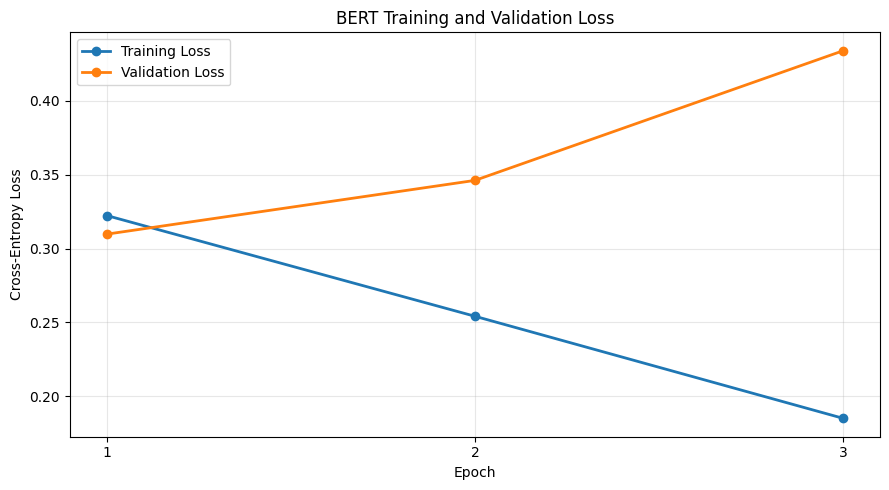

In [22]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("BERT Training and Validation Loss")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### D. Plot training and validation accuracy

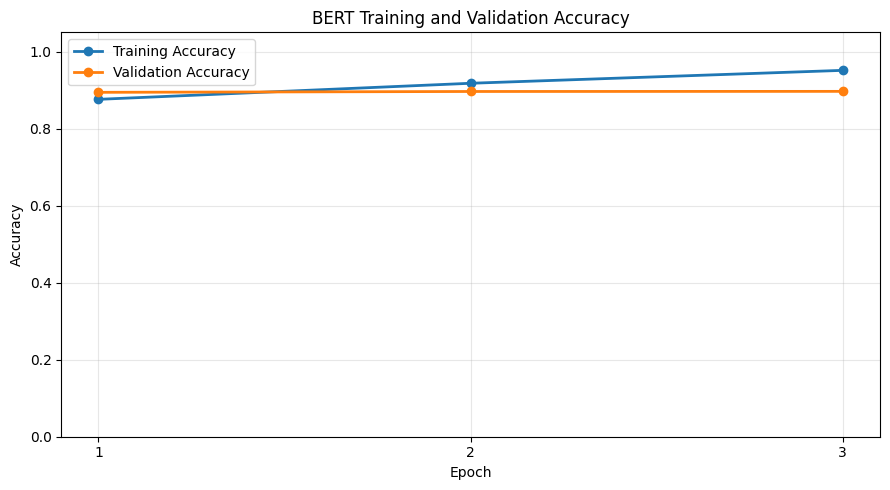

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT Training and Validation Accuracy")
plt.xticks(history_df["epoch"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### E. Plot validation metrics

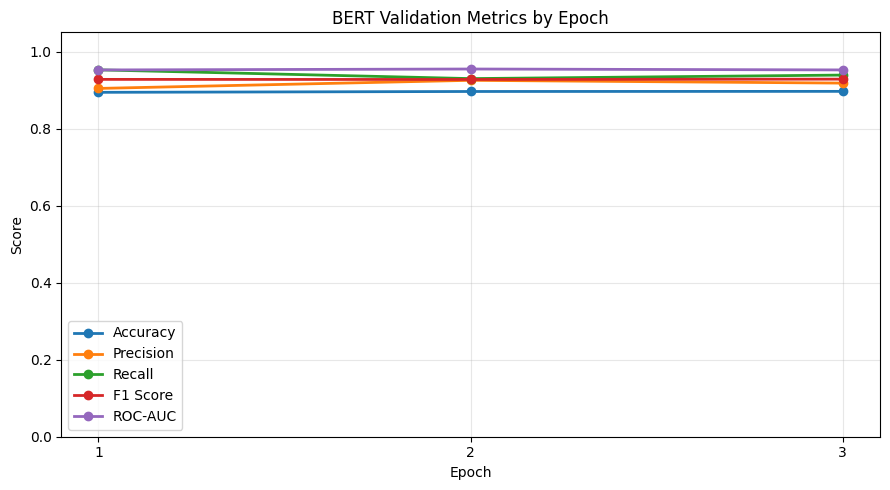

In [24]:
plt.figure(figsize=(9, 5))

for column, label in {
    "val_accuracy": "Accuracy",
    "val_precision": "Precision",
    "val_recall": "Recall",
    "val_f1": "F1 Score",
    "val_roc_auc": "ROC-AUC",
}.items():
    plt.plot(
        history_df["epoch"],
        history_df[column],
        marker="o",
        linewidth=2,
        label=label,
    )

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("BERT Validation Metrics by Epoch")
plt.xticks(history_df["epoch"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### F. Plot the learning-rate schedule

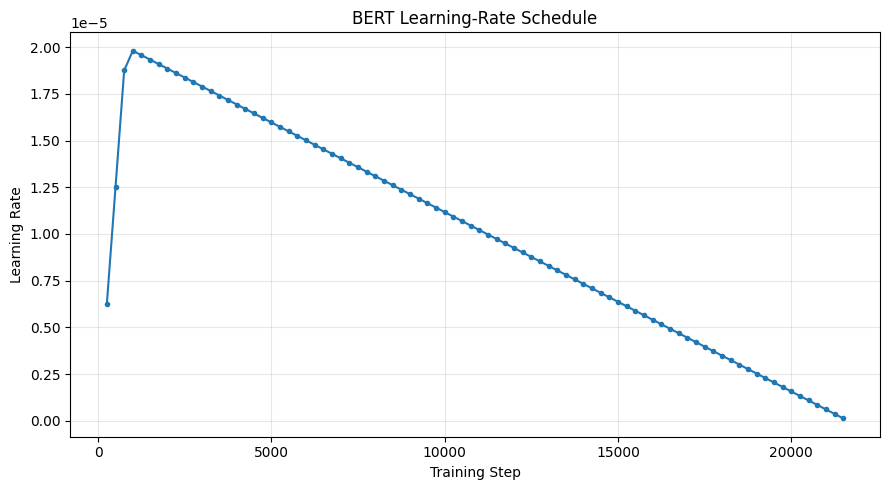

In [25]:
if not step_history_df.empty:
    plt.figure(figsize=(9, 5))

    plt.plot(
        step_history_df["step"],
        step_history_df["learning_rate"],
        marker="o",
        markersize=3,
    )

    plt.xlabel("Training Step")
    plt.ylabel("Learning Rate")
    plt.title("BERT Learning-Rate Schedule")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(
        "No step-level entries were recorded. "
        "This can occur when there are fewer than 250 total steps."
    )

## Step 7: Model Evaluation

The trained model is now evaluated on the held-out test set. The test split was not used to update the model weights or select hyperparameters.

In [26]:
all_preds = []
all_labels = []
all_positive_probabilities = []
all_confidences = []

model.eval()

with torch.no_grad():
    for batch in tqdm(
        test_dataloader,
        desc="Testing",
    ):
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        )

        logits = outputs.logits
        probabilities = torch.softmax(
            logits,
            dim=1,
        )
        predictions = torch.argmax(
            logits,
            dim=-1,
        )

        all_preds.extend(
            predictions.detach().cpu().numpy()
        )
        all_labels.extend(
            batch["label"].detach().cpu().numpy()
        )
        all_positive_probabilities.extend(
            probabilities[:, 1].detach().cpu().numpy()
        )
        all_confidences.extend(
            probabilities.max(dim=1).values.detach().cpu().numpy()
        )

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_positive_probabilities = np.array(
    all_positive_probabilities
)
all_confidences = np.array(all_confidences)

print("Number of test predictions:", len(all_preds))

Testing:   0%|          | 0/2004 [00:00<?, ?it/s]

Number of test predictions: 16025


### B. Compute and display test metrics

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

test_accuracy = accuracy_score(
    all_labels,
    all_preds,
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        zero_division=0,
    )
)

test_roc_auc = roc_auc_score(
    all_labels,
    all_positive_probabilities,
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

print("\nClassification report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0,
    )
)

Test Accuracy: 0.8947
Test Precision: 0.9017
Test Recall: 0.9567
Test F1-score: 0.9284
Test ROC-AUC: 0.9512

Classification report:
              precision    recall  f1-score   support

    Negative     0.8727    0.7398    0.8008      4585
    Positive     0.9017    0.9567    0.9284     11440

    accuracy                         0.8947     16025
   macro avg     0.8872    0.8483    0.8646     16025
weighted avg     0.8934    0.8947    0.8919     16025



### C. Visualize the confusion matrix

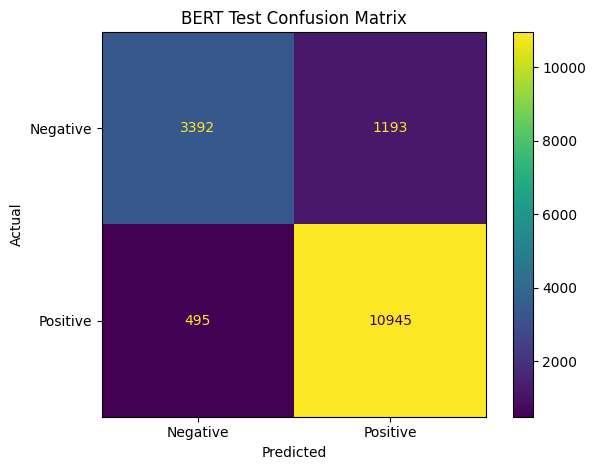

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_preds,
)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"],
)

display_object.plot(values_format="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Test Confusion Matrix")
plt.tight_layout()
plt.show()

### D. ROC curve

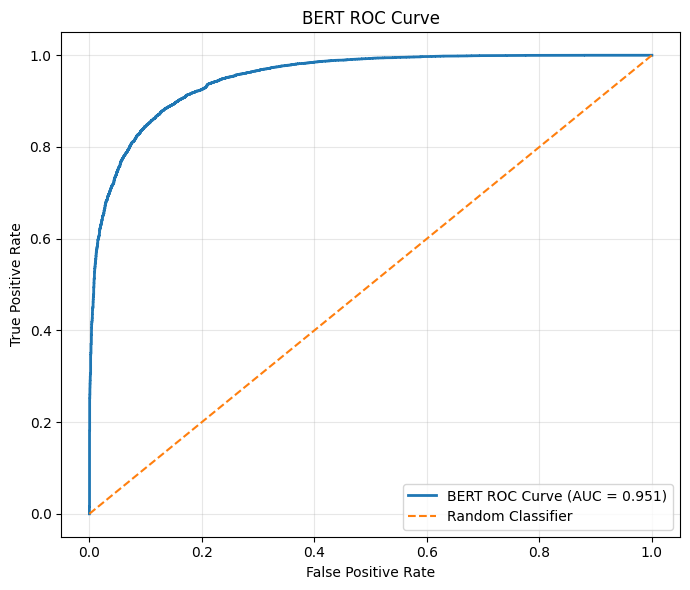

In [29]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, _ = roc_curve(
    all_labels,
    all_positive_probabilities,
)

plt.figure(figsize=(7, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"BERT ROC Curve (AUC = {test_roc_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BERT ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### E. Precision-recall curve

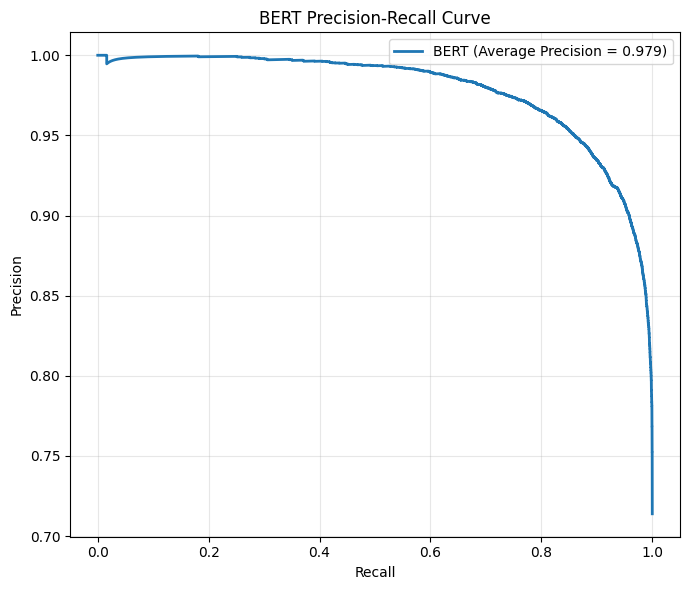

In [30]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
)

precision_values, recall_values, _ = precision_recall_curve(
    all_labels,
    all_positive_probabilities,
)

average_precision = average_precision_score(
    all_labels,
    all_positive_probabilities,
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=f"BERT (Average Precision = {average_precision:.3f})",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("BERT Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Inference and Analysis

In [31]:
def predict_sentiment(
    text,
    model,
    tokenizer,
    device,
):
    model.eval()

    inputs = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(
            outputs.logits,
            dim=1,
        )[0]

    predicted_label = int(
        torch.argmax(probabilities).item()
    )

    confidence = float(
        probabilities[predicted_label].item()
    )

    return {
        "label": predicted_label,
        "sentiment": label_names[predicted_label],
        "confidence": confidence,
        "negative_probability": float(
            probabilities[0].item()
        ),
        "positive_probability": float(
            probabilities[1].item()
        ),
    }


custom_reviews = [
    "The room was spotless and the staff made our stay wonderful.",
    "The bathroom was dirty and the service was extremely disappointing.",
    "The location was excellent, but the room was noisy and outdated.",
]

for review in custom_reviews:
    result = predict_sentiment(
        review,
        model,
        tokenizer,
        device,
    )

    print("Review:", review)
    print("Predicted sentiment:", result["sentiment"])
    print(f"Confidence: {result['confidence']:.2%}")
    print("---")

Review: The room was spotless and the staff made our stay wonderful.
Predicted sentiment: Positive
Confidence: 99.83%
---
Review: The bathroom was dirty and the service was extremely disappointing.
Predicted sentiment: Negative
Confidence: 99.75%
---
Review: The location was excellent, but the room was noisy and outdated.
Predicted sentiment: Negative
Confidence: 90.21%
---


### B. Create a table of tested reviews and predictions

The original test dataframe remains in the same order as `test_dataloader` because the test loader was created with `shuffle=False`.

In [32]:
results_df = test_df.copy()

results_df["actual_label"] = all_labels
results_df["predicted_label"] = all_preds
results_df["actual_sentiment"] = (
    results_df["actual_label"].map(label_names)
)
results_df["predicted_sentiment"] = (
    results_df["predicted_label"].map(label_names)
)
results_df["confidence"] = all_confidences
results_df["confidence_percent"] = (
    results_df["confidence"] * 100
).round(2)
results_df["positive_probability"] = (
    all_positive_probabilities
)
results_df["correct"] = (
    results_df["actual_label"]
    == results_df["predicted_label"]
)

display(
    results_df[
        [
            "review_text",
            "actual_sentiment",
            "predicted_sentiment",
            "confidence_percent",
            "correct",
        ]
    ].sample(
        n=min(10, len(results_df)),
        random_state=SEED,
    )
)

,review_text,actual_sentiment,predicted_sentiment,confidence_percent,correct
4829,"“Sorry, service at frontdesk was not o.k.” I h...",Negative,Negative,99.489998,True
1962,“Pricey But Perfect” If you want to stay in a ...,Positive,Positive,99.839996,True
2546,"“Quality masquerading as Clarion - Not bad, bu...",Negative,Positive,57.880001,False
4768,“Beautiful property for families and couples” ...,Positive,Positive,99.779999,True
4866,“OK but I would stay elsewhere” This is my sec...,Negative,Negative,98.919998,True
12212,“Great airport hotel” Came here to spend the n...,Positive,Positive,99.769997,True
15494,“Best value in New York City” The hotel is VER...,Positive,Positive,99.730003,True
14413,“More of a business type hotel” My husband and...,Negative,Negative,65.599998,True
3991,“コスパ最高” 最近ポートオーそりティ近辺にホテルが多く立ってきた。ここも隣はマリオット系、...,Positive,Positive,74.889999,True
1323,“Good value but some issues” This is a brand n...,Positive,Negative,55.410000,False


### C. Analyze misclassifications

Misclassified reviews may contain:

- Mixed positive and negative statements
- Sarcasm
- Unusual wording
- Ratings that do not match the written review
- Important sentiment appearing after the 256-token truncation point

In [33]:
misclassified_indices = np.where(
    all_preds != all_labels
)[0]

print(
    "Number of misclassified test reviews:",
    len(misclassified_indices),
)

for index in misclassified_indices[:5]:
    index = int(index)

    print("Review:", test_df.iloc[index]["review_text"])
    print(
        "True label:",
        all_labels[index],
        f"({label_names[int(all_labels[index])]})",
    )
    print(
        "Predicted label:",
        all_preds[index],
        f"({label_names[int(all_preds[index])]})",
    )
    print(
        f"Confidence: {all_confidences[index]:.2%}"
    )
    print("---")

Number of misclassified test reviews: 1688
Review: “Lots of potential, but major kinks” I stayed at Hotel Felix for four nights in May at a priceline rate of $150/night. On the first night, after a long night on the town, I was horrified when I pulled back the covers and discovered several (and I'm talking 10-12) strands of someone else's hair stuck to the sheets. I've stayed in tons of hotels around the world and have never seen anything like this. 
I complained to management and left a very courteous note for the housekeeping staff. To their credit, I never had an issue after that. Still, this is unacceptable. I hope they step up their game, because it's a cute little hotel. Rooms are small, but well appointed and the bath products were great. The lobby/bar area was usually crowded a la W hotels, giving it a trendy vibe. Staff were friendly. Parking was outrageously high, but par for the course in the area.
True label: 0 (Negative)
Predicted label: 1 (Positive)
Confidence: 54.87%
---

### D. Display the model's most confident mistakes

In [34]:
most_confident_errors = (
    results_df[~results_df["correct"]]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .head(10)
)

display(
    most_confident_errors[
        [
            "review_text",
            "actual_sentiment",
            "predicted_sentiment",
            "confidence_percent",
        ]
    ]
)

,review_text,actual_sentiment,predicted_sentiment,confidence_percent
7956,"“Very good experience” A clean, convenient pla...",Negative,Positive,99.849998
10129,“Very pleasant experience - would stay here ag...,Negative,Positive,99.839996
5865,"“Lovely Hotel” A reasonably priced, clean Hote...",Negative,Positive,99.830002
12265,“Excellent service” I am platinum Marriott rew...,Negative,Positive,99.830002
136,“Newly refurbished: Clean & Comfy” We missed t...,Negative,Positive,99.830002
2180,“Solid Business Hotel” Very solid service and ...,Negative,Positive,99.830002
11081,“very good service” This is my second time at ...,Negative,Positive,99.830002
14459,“Pleasant stay” I just came back from a stay a...,Negative,Positive,99.830002
3244,“Great hotel” My husband and I stayed here for...,Negative,Positive,99.830002
3972,“Almost Perfect.” I traveled to Memphis on a o...,Negative,Positive,99.830002


### E. Display the least confident predictions

In [35]:
least_confident_predictions = (
    results_df
    .sort_values(
        "confidence",
        ascending=True,
    )
    .head(10)
)

display(
    least_confident_predictions[
        [
            "review_text",
            "actual_sentiment",
            "predicted_sentiment",
            "confidence_percent",
            "correct",
        ]
    ]
)

,review_text,actual_sentiment,predicted_sentiment,confidence_percent,correct
10896,"“Nice, but rather corporate Westin” I stayed i...",Positive,Positive,50.009998,True
6670,“Rooms - great! Location - not so much.” If th...,Positive,Positive,50.040001,True
7429,“Large room at reasonable price” Reservation t...,Positive,Negative,50.040001,False
14065,“A real mixed bag” Sir Francis Drake hotel is ...,Positive,Negative,50.099998,False
118,“muy bueno para familias” Es un muy buen lugar...,Positive,Negative,50.110001,False
3582,“I like the charm of this hotel” I like the Ol...,Positive,Negative,50.209999,False
12763,"“Decent hotel, great perks, kid-friendly” Stay...",Positive,Negative,50.310001,False
6946,"“very good location and quality, but room and ...",Positive,Negative,50.439999,False
6314,“Perfectly Adequate” Everything about this hot...,Positive,Positive,50.450001,True
15081,“great location for baseball” we stayed here f...,Negative,Negative,50.470001,True


## Step 9: Save the trained model and results

In [36]:
MODEL_OUTPUT_DIR = "./models/bert_hotel_sentiment_pytorch"

os.makedirs(
    MODEL_OUTPUT_DIR,
    exist_ok=True,
)

model.save_pretrained(MODEL_OUTPUT_DIR)
tokenizer.save_pretrained(MODEL_OUTPUT_DIR)

history_df.to_csv(
    "bert_pytorch_training_history.csv",
    index=False,
)

results_df.to_csv(
    "bert_pytorch_test_predictions.csv",
    index=False,
)

test_metrics_df = pd.DataFrame([
    {
        "accuracy": test_accuracy,
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
        "roc_auc": test_roc_auc,
        "training_minutes": training_minutes,
    }
])

test_metrics_df.to_csv(
    "bert_pytorch_test_metrics.csv",
    index=False,
)

print("Saved model to:", MODEL_OUTPUT_DIR)
print("Saved training history.")
print("Saved test predictions.")
print("Saved test metrics.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: ./models/bert_hotel_sentiment_pytorch
Saved training history.
Saved test predictions.
Saved test metrics.
